In [29]:
"""
NOTEBOOK 1 : CHARGEMENT ET NETTOYAGE DES DONNÉES
================================================
Objectif : Charger les données brutes, vérifier leur qualité, 
           détecter les outliers, et sauvegarder une version nettoyée
"""

# Imports des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
%matplotlib inline

# Configuration pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("="*80)
print("NOTEBOOK 1 : CHARGEMENT ET NETTOYAGE DES DONNÉES")
print("="*80)
print("✅ Bibliothèques importées avec succès!")
print(f"📦 Pandas version: {pd.__version__}")
print(f"📦 NumPy version: {np.__version__}")

NOTEBOOK 1 : CHARGEMENT ET NETTOYAGE DES DONNÉES
✅ Bibliothèques importées avec succès!
📦 Pandas version: 3.0.0
📦 NumPy version: 2.3.0


In [30]:
# Chargement des données depuis le fichier Excel


print("\n" + "="*80)
print("CHARGEMENT DES DONNÉES")
print("="*80)

# Chemin vers le fichier Excel
file_path = '../data/raw/2006-2010_database_bvlac_bruelle.xlsx'

# Charger la feuille 'database'
df = pd.read_excel(file_path, sheet_name='database')

print(f"✅ Données chargées avec succès!")
print(f"\n📊 Dimensions du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\n📅 Période couverte : {df['crop_season'].unique()}")
print(f"\n🏘️ Villages inclus : {df['village'].unique()}")


CHARGEMENT DES DONNÉES
✅ Données chargées avec succès!

📊 Dimensions du dataset : 3803 lignes × 19 colonnes

📅 Période couverte : <StringArray>
['Y06_07', 'Y07_08', 'Y08_09', 'Y09_10']
Length: 4, dtype: str

🏘️ Villages inclus : <StringArray>
['Antsahamamy', 'Ambohimiarina', 'Ambohitsilaozana', 'Ambongabe',
 'Ampitatsimo']
Length: 5, dtype: str


In [31]:
# Aperçu des premières lignes
print("\n" + "="*80)
print("APERÇU DES DONNÉES (10 premières lignes)")
print("="*80)

display(df.head(10))

print("\n" + "="*80)
print("INFORMATIONS SUR LES COLONNES")
print("="*80)
print(df.info())


APERÇU DES DONNÉES (10 premières lignes)


,id_field,crop_season,village,soil,area,tillage_system,CA_year,sow_date,x24d,glypho,manure,urea,npk,nitrogen,rain_sow,rain_flow,rain_cycle,rain_year,yield
0,F2006070001,Y06_07,Antsahamamy,hillside,10.00,till,Y0,2006-12-27,N,N,1666.70,70.00,150.00,48.70,65.20,225.50,1263.00,1331.20,3150.00
1,F2006070002,Y06_07,Antsahamamy,hillside,15.00,ca,Y1,2006-12-26,N,N,2500.00,0.00,0.00,0.00,63.70,103.50,1263.00,1331.20,805.00
2,F2006070003,Y06_07,Antsahamamy,lowland,3.10,till,Y0,2006-12-20,N,N,4166.70,0.00,64.70,7.12,44.70,6.00,1307.70,1331.20,3786.40
3,F2006070004,Y06_07,Antsahamamy,lowland,6.30,till,Y0,2006-12-20,N,N,4000.00,31.70,47.60,19.82,44.70,6.00,1307.70,1331.20,3714.30
4,F2006070005,Y06_07,Antsahamamy,hillside,41.00,till,Y0,2006-12-21,N,N,3225.80,36.60,73.20,24.89,44.70,6.00,1307.70,1331.20,3248.80
5,F2006070006,Y06_07,Antsahamamy,lowland,4.20,till,Y0,2006-12-18,N,N,9523.80,47.60,95.20,32.37,49.50,6.00,1307.70,1331.20,2142.90
6,F2006070007,Y06_07,Antsahamamy,hillside,15.00,till,Y0,2006-12-19,N,N,3333.30,100.00,100.00,57.00,49.50,6.00,1307.70,1331.20,1500.00
7,F2006070008,Y06_07,Antsahamamy,hillside,10.80,till,Y0,2006-12-20,N,N,3333.30,0.00,55.60,6.12,44.70,6.00,1307.70,1331.20,1805.60
8,F2006070009,Y06_07,Antsahamamy,lowland,8.00,till,Y0,2006-12-29,N,N,4166.70,50.00,125.00,36.75,72.30,280.00,1263.00,1331.20,3500.00
9,F2006070010,Y06_07,Antsahamamy,hillside,6.00,till,Y0,2006-12-06,N,N,4166.70,33.30,0.00,15.32,17.80,305.60,1323.00,1331.20,2816.70



INFORMATIONS SUR LES COLONNES
<class 'pandas.DataFrame'>
RangeIndex: 3803 entries, 0 to 3802
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_field        3803 non-null   str           
 1   crop_season     3803 non-null   str           
 2   village         3803 non-null   str           
 3   soil            3803 non-null   str           
 4   area            3803 non-null   float64       
 5   tillage_system  3803 non-null   str           
 6   CA_year         3803 non-null   str           
 7   sow_date        3803 non-null   datetime64[us]
 8   x24d            3803 non-null   str           
 9   glypho          3803 non-null   str           
 10  manure          3803 non-null   float64       
 11  urea            3803 non-null   float64       
 12  npk             3803 non-null   float64       
 13  nitrogen        3803 non-null   float64       
 14  rain_sow        3803 non-null   floa

In [32]:
print("\n" + "="*80)
print("TYPES DE DONNÉES")
print("="*80)

# Créer un DataFrame résumé
types_summary = pd.DataFrame({
    'Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Null Count': df.isnull().sum(),
    'Unique Values': df.nunique()
})

display(types_summary)

# Identifier les variables catégorielles et numériques
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n📝 Variables catégorielles ({len(categorical_cols)}) : {categorical_cols}")
print(f"\n🔢 Variables numériques ({len(numerical_cols)}) : {numerical_cols}")


TYPES DE DONNÉES


,Type,Non-Null Count,Null Count,Unique Values
id_field,str,3803,0,3803
crop_season,str,3803,0,4
village,str,3803,0,5
soil,str,3803,0,2
area,float64,3803,0,333
tillage_system,str,3803,0,2
CA_year,str,3803,0,5
sow_date,datetime64[us],3803,0,278
x24d,str,3803,0,2
glypho,str,3803,0,2



📝 Variables catégorielles (8) : ['id_field', 'crop_season', 'village', 'soil', 'tillage_system', 'CA_year', 'x24d', 'glypho']

🔢 Variables numériques (10) : ['area', 'manure', 'urea', 'npk', 'nitrogen', 'rain_sow', 'rain_flow', 'rain_cycle', 'rain_year', 'yield']


In [33]:
print("\n" + "="*80)
print("ANALYSE DES VALEURS MANQUANTES")
print("="*80)

# Calcul des valeurs manquantes
missing_data = pd.DataFrame({
    'Colonne': df.columns,
    'Valeurs manquantes': df.isnull().sum(),
    'Pourcentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_data = missing_data[missing_data['Valeurs manquantes'] > 0].sort_values(
    'Valeurs manquantes', ascending=False
)

if len(missing_data) == 0:
    print("✅ EXCELLENT ! Aucune valeur manquante détectée dans le dataset.")
else:
    print(f"⚠️ {len(missing_data)} colonnes avec des valeurs manquantes :")
    display(missing_data)
    
    # Visualisation
    fig, ax = plt.subplots(figsize=(10, 6))
    missing_data.plot(x='Colonne', y='Pourcentage (%)', kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Pourcentage de valeurs manquantes (%)', fontweight='bold')
    ax.set_title('Distribution des valeurs manquantes par variable', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()


ANALYSE DES VALEURS MANQUANTES
✅ EXCELLENT ! Aucune valeur manquante détectée dans le dataset.


In [34]:
print("\n" + "="*80)
print("VÉRIFICATION DES DOUBLONS")
print("="*80)

# Nombre de doublons complets
n_duplicates = df.duplicated().sum()
print(f"🔍 Nombre de lignes dupliquées (toutes colonnes) : {n_duplicates}")

# Doublons sur id_field + crop_season (même parcelle, même année)
n_duplicates_key = df.duplicated(subset=['id_field', 'crop_season']).sum()
print(f"🔍 Nombre de doublons (id_field + crop_season) : {n_duplicates_key}")

if n_duplicates > 0:
    print("\n⚠️ Doublons détectés :")
    display(df[df.duplicated(keep=False)].sort_values(['id_field', 'crop_season']))
else:
    print("✅ Aucun doublon détecté.")


VÉRIFICATION DES DOUBLONS
🔍 Nombre de lignes dupliquées (toutes colonnes) : 0
🔍 Nombre de doublons (id_field + crop_season) : 0
✅ Aucun doublon détecté.


In [35]:
print("\n" + "="*80)
print("STATISTIQUES DESCRIPTIVES DES VARIABLES NUMÉRIQUES")
print("="*80)

# Statistiques de base
stats_desc = df[numerical_cols].describe().T

# Ajouter des statistiques supplémentaires
stats_desc['CV (%)'] = (stats_desc['std'] / stats_desc['mean'] * 100).round(2)
stats_desc['skewness'] = df[numerical_cols].skew().round(2)
stats_desc['kurtosis'] = df[numerical_cols].kurtosis().round(2)

# Réorganiser les colonnes
stats_desc = stats_desc[['count', 'mean', 'std', 'CV (%)', 'min', '25%', '50%', '75%', 'max', 'skewness', 'kurtosis']]

display(stats_desc)

# Sauvegarder
stats_desc.to_csv('../results/stats_descriptives_brutes.csv')
print("\n✅ Statistiques sauvegardées dans 'results/stats_descriptives_brutes.csv'")


STATISTIQUES DESCRIPTIVES DES VARIABLES NUMÉRIQUES


,count,mean,std,CV (%),min,25%,50%,75%,max,skewness,kurtosis
area,3803.00,8.89,17.26,194.12,0.00,0.10,0.50,11.35,260.00,4.92,42.41
manure,3803.00,1198.83,1676.28,139.83,0.00,0.00,0.00,2500.00,11976.00,1.35,1.50
urea,3803.00,17.26,30.26,175.36,0.00,0.00,0.00,33.30,150.00,1.71,2.14
npk,3803.00,22.21,48.58,218.69,0.00,0.00,0.00,0.00,300.00,2.33,4.88
nitrogen,3803.00,10.38,17.31,166.76,0.00,0.00,0.00,18.40,91.45,1.79,2.77
rain_sow,3803.00,76.60,55.01,71.82,0.00,32.30,66.60,115.60,357.80,0.77,0.08
rain_flow,3803.00,123.07,108.15,87.88,0.00,33.45,97.60,196.05,430.70,0.81,-0.48
rain_cycle,3803.00,919.38,160.33,17.44,443.40,803.90,925.40,982.40,1325.50,0.60,0.17
rain_year,3803.00,1114.09,161.91,14.53,801.70,1062.20,1105.00,1288.70,1331.40,-0.27,-0.85
yield,3803.00,2566.53,908.32,35.39,318.00,1915.60,2546.70,3142.90,5350.00,0.15,-0.36



✅ Statistiques sauvegardées dans 'results/stats_descriptives_brutes.csv'


In [36]:
print("\n" + "="*80)
print("DISTRIBUTION DES VARIABLES CATÉGORIELLES")
print("="*80)

for col in categorical_cols:
    print(f"\n📊 {col.upper()} :")
    print(df[col].value_counts())
    print(f"   → {df[col].nunique()} modalités uniques")


DISTRIBUTION DES VARIABLES CATÉGORIELLES

📊 ID_FIELD :
id_field
F2006070001    1
F2006070002    1
F2006070003    1
F2006070004    1
F2006070005    1
              ..
F2009101180    1
F2009101181    1
F2009101182    1
F2009101183    1
F2009101184    1
Name: count, Length: 3803, dtype: int64
   → 3803 modalités uniques

📊 CROP_SEASON :
crop_season
Y09_10    1151
Y07_08     978
Y08_09     958
Y06_07     716
Name: count, dtype: int64
   → 4 modalités uniques

📊 VILLAGE :
village
Ambohimiarina       1584
Antsahamamy          977
Ambohitsilaozana     757
Ambongabe            392
Ampitatsimo           93
Name: count, dtype: int64
   → 5 modalités uniques

📊 SOIL :
soil
lowland     2946
hillside     857
Name: count, dtype: int64
   → 2 modalités uniques

📊 TILLAGE_SYSTEM :
tillage_system
till    1931
ca      1872
Name: count, dtype: int64
   → 2 modalités uniques

📊 CA_YEAR :
CA_year
Y0     1931
Y1     1016
Y2      446
Y3      234
Y4+     176
Name: count, dtype: int64
   → 5 modalités uniques


DÉTECTION DES OUTLIERS - RENDEMENT (yield)
📊 Statistiques du rendement :
   Q1 (25%) : 1915.60 kg/ha
   Q3 (75%) : 3142.90 kg/ha
   IQR : 1227.30 kg/ha
   Borne inférieure : 74.65 kg/ha
   Borne supérieure : 4983.85 kg/ha

🔍 Nombre d'outliers (méthode IQR) : 17 (0.45%)
🔍 Nombre d'outliers (Z-score > 3) : 2 (0.05%)


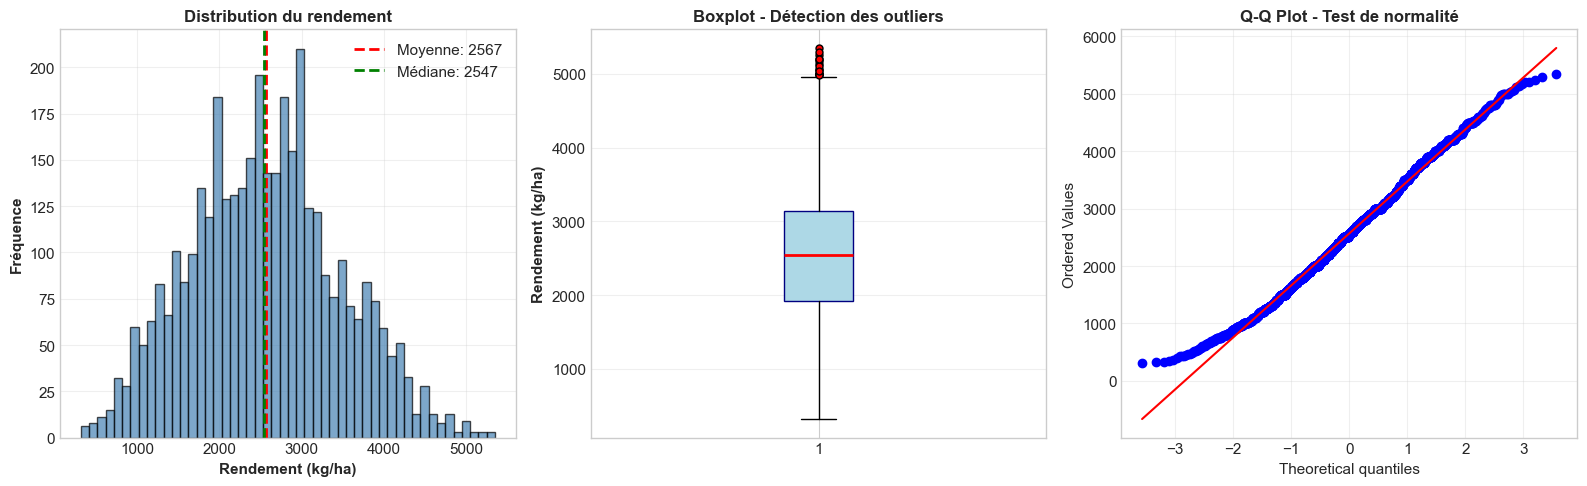


✅ Figure sauvegardée : 'figures/01_outliers_rendement.png'


In [37]:
print("\n" + "="*80)
print("DÉTECTION DES OUTLIERS - RENDEMENT (yield)")
print("="*80)

# Méthode IQR (InterQuartile Range)
Q1 = df['yield'].quantile(0.25)
Q3 = df['yield'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['yield'] < lower_bound) | (df['yield'] > upper_bound)]

print(f"📊 Statistiques du rendement :")
print(f"   Q1 (25%) : {Q1:.2f} kg/ha")
print(f"   Q3 (75%) : {Q3:.2f} kg/ha")
print(f"   IQR : {IQR:.2f} kg/ha")
print(f"   Borne inférieure : {lower_bound:.2f} kg/ha")
print(f"   Borne supérieure : {upper_bound:.2f} kg/ha")
print(f"\n🔍 Nombre d'outliers (méthode IQR) : {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.2f}%)")

# Méthode Z-score
z_scores = np.abs(stats.zscore(df['yield']))
outliers_zscore = df[z_scores > 3]
print(f"🔍 Nombre d'outliers (Z-score > 3) : {len(outliers_zscore)} ({len(outliers_zscore)/len(df)*100:.2f}%)")

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogramme
axes[0].hist(df['yield'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['yield'].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {df["yield"].mean():.0f}')
axes[0].axvline(df['yield'].median(), color='green', linestyle='--', linewidth=2, label=f'Médiane: {df["yield"].median():.0f}')
axes[0].set_xlabel('Rendement (kg/ha)', fontweight='bold')
axes[0].set_ylabel('Fréquence', fontweight='bold')
axes[0].set_title('Distribution du rendement', fontweight='bold', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
bp = axes[1].boxplot(df['yield'], vert=True, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', color='navy'),
                      medianprops=dict(color='red', linewidth=2),
                      flierprops=dict(marker='o', markerfacecolor='red', markersize=5))
axes[1].set_ylabel('Rendement (kg/ha)', fontweight='bold')
axes[1].set_title('Boxplot - Détection des outliers', fontweight='bold', fontsize=12)
axes[1].grid(alpha=0.3, axis='y')

# Q-Q plot
stats.probplot(df['yield'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot - Test de normalité', fontweight='bold', fontsize=12)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/01_outliers_rendement.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Figure sauvegardée : 'figures/01_outliers_rendement.png'")

In [38]:
print("\n" + "="*80)
print("TEST DE NORMALITÉ DU RENDEMENT")
print("="*80)

# Test de Shapiro-Wilk (sur un échantillon si dataset trop grand)
if len(df) > 5000:
    sample = df['yield'].sample(n=5000, random_state=42)
    statistic, p_value = stats.shapiro(sample)
    print("⚠️ Dataset > 5000 lignes → test sur échantillon de 5000 observations")
else:
    statistic, p_value = stats.shapiro(df['yield'])

print(f"\n📊 Test de Shapiro-Wilk :")
print(f"   Statistique W : {statistic:.6f}")
print(f"   p-value : {p_value:.6e}")

if p_value > 0.05:
    print(f"   ✅ Distribution NORMALE (p > 0.05)")
else:
    print(f"   ⚠️ Distribution NON NORMALE (p < 0.05)")

# Test de Kolmogorov-Smirnov
statistic_ks, p_value_ks = stats.kstest(df['yield'], 'norm', 
                                         args=(df['yield'].mean(), df['yield'].std()))
print(f"\n📊 Test de Kolmogorov-Smirnov :")
print(f"   Statistique : {statistic_ks:.6f}")
print(f"   p-value : {p_value_ks:.6e}")

# Skewness et Kurtosis
skewness = df['yield'].skew()
kurtosis = df['yield'].kurtosis()

print(f"\n📊 Mesures de forme :")
print(f"   Asymétrie (Skewness) : {skewness:.4f}")
if abs(skewness) < 0.5:
    print(f"      → Distribution approximativement symétrique")
elif skewness > 0:
    print(f"      → Distribution asymétrique à droite (queue longue vers valeurs élevées)")
else:
    print(f"      → Distribution asymétrique à gauche (queue longue vers valeurs faibles)")

print(f"\n   Aplatissement (Kurtosis) : {kurtosis:.4f}")
if abs(kurtosis) < 0.5:
    print(f"      → Distribution mesokurtique (normale)")
elif kurtosis > 0:
    print(f"      → Distribution leptokurtique (pic aigu, queues épaisses)")
else:
    print(f"      → Distribution platykurtique (pic aplati, queues fines)")


TEST DE NORMALITÉ DU RENDEMENT

📊 Test de Shapiro-Wilk :
   Statistique W : 0.995133
   p-value : 6.307699e-10
   ⚠️ Distribution NON NORMALE (p < 0.05)

📊 Test de Kolmogorov-Smirnov :
   Statistique : 0.028360
   p-value : 4.323282e-03

📊 Mesures de forme :
   Asymétrie (Skewness) : 0.1486
      → Distribution approximativement symétrique

   Aplatissement (Kurtosis) : -0.3605
      → Distribution mesokurtique (normale)


In [39]:
print("\n" + "="*80)
print("DÉCISION : TRAITEMENT DES OUTLIERS")
print("="*80)

# Pour un dataset agricole, les valeurs extrêmes peuvent être réelles
# Option 1 : Conserver tous les outliers (recommandé pour agriculture)
# Option 2 : Supprimer seulement les outliers extrêmes (Z-score > 3)
# Option 3 : Winsorization (plafonner aux percentiles)

decision = "conserver"  # Modifier selon ton choix : "conserver", "supprimer", "winsorize"

if decision == "conserver":
    df_clean = df.copy()
    print("✅ Décision : CONSERVER tous les outliers")
    print("   Justification : En agriculture, les rendements extrêmes peuvent refléter")
    print("   des conditions réelles (excellente/mauvaise année, parcelle exceptionnelle)")
    
elif decision == "supprimer":
    # Supprimer outliers extrêmes (Z-score > 3)
    z_scores = np.abs(stats.zscore(df['yield']))
    df_clean = df[z_scores <= 3].copy()
    print(f"✅ Décision : SUPPRIMER les outliers extrêmes (Z-score > 3)")
    print(f"   {len(df) - len(df_clean)} observations supprimées")
    
elif decision == "winsorize":
    # Winsorization : plafonner aux percentiles 1% et 99%
    from scipy.stats.mstats import winsorize
    df_clean = df.copy()
    df_clean['yield'] = winsorize(df['yield'], limits=[0.01, 0.01])
    print("✅ Décision : WINSORIZATION (plafonner aux percentiles 1% et 99%)")

print(f"\n📊 Dataset final : {len(df_clean)} observations")


DÉCISION : TRAITEMENT DES OUTLIERS
✅ Décision : CONSERVER tous les outliers
   Justification : En agriculture, les rendements extrêmes peuvent refléter
   des conditions réelles (excellente/mauvaise année, parcelle exceptionnelle)

📊 Dataset final : 3803 observations


In [40]:
print("\n" + "="*80)
print("VÉRIFICATION DE COHÉRENCE DES DONNÉES")
print("="*80)

# Vérifier les valeurs négatives ou nulles là où ça n'a pas de sens
checks = []

# Rendement
n_negative_yield = (df_clean['yield'] <= 0).sum()
checks.append(('Rendement négatif ou nul', n_negative_yield))

# Superficie
n_negative_area = (df_clean['area'] < 0).sum()
checks.append(('Superficie négative', n_negative_area))

# Pluviométrie
for col in ['rain_sow', 'rain_flow', 'rain_cycle', 'rain_year']:
    n_negative = (df_clean[col] < 0).sum()
    checks.append((f'{col} négatif', n_negative))

# Fertilisation
for col in ['manure', 'urea', 'npk', 'nitrogen']:
    n_negative = (df_clean[col] < 0).sum()
    checks.append((f'{col} négatif', n_negative))

# Afficher les résultats
print("\n📋 Résultats des vérifications :")
for check_name, count in checks:
    status = "✅" if count == 0 else "⚠️"
    print(f"{status} {check_name}: {count} observations")

# Vérifier la cohérence temporelle
print("\n📅 Vérification des dates de semis :")
try:
    df_clean['sow_date_parsed'] = pd.to_datetime(df_clean['sow_date'])
    print(f"   Date de semis min : {df_clean['sow_date_parsed'].min()}")
    print(f"   Date de semis max : {df_clean['sow_date_parsed'].max()}")
except:
    print("   ⚠️ Impossible de parser les dates de semis")


VÉRIFICATION DE COHÉRENCE DES DONNÉES

📋 Résultats des vérifications :
✅ Rendement négatif ou nul: 0 observations
✅ Superficie négative: 0 observations
✅ rain_sow négatif: 0 observations
✅ rain_flow négatif: 0 observations
✅ rain_cycle négatif: 0 observations
✅ rain_year négatif: 0 observations
✅ manure négatif: 0 observations
✅ urea négatif: 0 observations
✅ npk négatif: 0 observations
✅ nitrogen négatif: 0 observations

📅 Vérification des dates de semis :
   Date de semis min : 2006-10-14 00:00:00
   Date de semis max : 2010-01-16 00:00:00


In [41]:
print("\n" + "="*80)
print("SAUVEGARDE DES DONNÉES NETTOYÉES")
print("="*80)

# Sauvegarder le dataset nettoyé
output_path = '../data/processed/data_clean.csv'
df_clean.to_csv(output_path, index=False)

print(f"✅ Données nettoyées sauvegardées : {output_path}")
print(f"\n📊 Résumé final :")
print(f"   - Observations initiales : {len(df)}")
print(f"   - Observations finales : {len(df_clean)}")
print(f"   - Observations supprimées : {len(df) - len(df_clean)}")
print(f"   - Variables : {len(df_clean.columns)}")


SAUVEGARDE DES DONNÉES NETTOYÉES
✅ Données nettoyées sauvegardées : ../data/processed/data_clean.csv

📊 Résumé final :
   - Observations initiales : 3803
   - Observations finales : 3803
   - Observations supprimées : 0
   - Variables : 20


In [42]:
print("\n" + "="*80)
print("RAPPORT DE SYNTHÈSE - NETTOYAGE DES DONNÉES")
print("="*80)

rapport = f"""
📋 RÉSUMÉ DU NETTOYAGE :

1️⃣ CHARGEMENT :
   ✅ {len(df)} observations chargées
   ✅ {len(df.columns)} variables
   ✅ Période : {df['crop_season'].min()} à {df['crop_season'].max()}
   
2️⃣ QUALITÉ DES DONNÉES :
   ✅ Valeurs manquantes : {df.isnull().sum().sum()} ({df.isnull().sum().sum()/df.size*100:.2f}%)
   ✅ Doublons : {df.duplicated().sum()}
   
3️⃣ OUTLIERS :
   📊 Outliers IQR : {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.2f}%)
   📊 Outliers Z-score : {len(outliers_zscore)} ({len(outliers_zscore)/len(df)*100:.2f}%)
   ✅ Décision : {decision.upper()}
   
4️⃣ NORMALITÉ :
   📊 Shapiro-Wilk p-value : {p_value:.6e}
   📊 Skewness : {skewness:.4f}
   📊 Kurtosis : {kurtosis:.4f}
   
5️⃣ DATASET FINAL :
   ✅ {len(df_clean)} observations
   ✅ {len(df_clean.columns)} variables
   ✅ Sauvegardé dans : {output_path}

🎯 PROCHAINE ÉTAPE : Notebook 2 - Analyse Exploratoire (EDA)
"""

print(rapport)

# Sauvegarder le rapport
with open('../results/01_rapport_nettoyage.txt', 'w', encoding='utf-8') as f:
    f.write(rapport)
    
print("✅ Rapport sauvegardé : 'results/01_rapport_nettoyage.txt'")


RAPPORT DE SYNTHÈSE - NETTOYAGE DES DONNÉES

📋 RÉSUMÉ DU NETTOYAGE :

1️⃣ CHARGEMENT :
   ✅ 3803 observations chargées
   ✅ 19 variables
   ✅ Période : Y06_07 à Y09_10

2️⃣ QUALITÉ DES DONNÉES :
   ✅ Valeurs manquantes : 0 (0.00%)
   ✅ Doublons : 0

3️⃣ OUTLIERS :
   📊 Outliers IQR : 17 (0.45%)
   📊 Outliers Z-score : 2 (0.05%)
   ✅ Décision : CONSERVER

4️⃣ NORMALITÉ :
   📊 Shapiro-Wilk p-value : 6.307699e-10
   📊 Skewness : 0.1486
   📊 Kurtosis : -0.3605

5️⃣ DATASET FINAL :
   ✅ 3803 observations
   ✅ 20 variables
   ✅ Sauvegardé dans : ../data/processed/data_clean.csv

🎯 PROCHAINE ÉTAPE : Notebook 2 - Analyse Exploratoire (EDA)

✅ Rapport sauvegardé : 'results/01_rapport_nettoyage.txt'
